# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(f"df_hh_income have {df_hh_income.shape[0]} rows and {df_hh_income.shape[1]} columns")
print(f"df_pct_poverty have {df_pct_poverty.shape[0]} rows and {df_pct_poverty.shape[1]} columns")
print(f"df_pct_completed_hs have {df_pct_completed_hs.shape[0]} rows and {df_pct_completed_hs.shape[1]} columns")
print(f"df_share_race_city have {df_share_race_city.shape[0]} rows and {df_share_race_city.shape[1]} columns")
print(f"df_fatalities have {df_fatalities.shape[0]} rows and {df_fatalities.shape[1]} columns")

df_hh_income have 29322 rows and 3 columns
df_pct_poverty have 29329 rows and 3 columns
df_pct_completed_hs have 29329 rows and 3 columns
df_share_race_city have 29268 rows and 7 columns
df_fatalities have 2535 rows and 14 columns


In [6]:
print(f"df_hh_income have columns: \n {df_hh_income.columns} columns")
print(f"df_pct_poverty have  columns:\n {df_pct_poverty.columns} columns")
print(f"df_pct_completed_hs have  columns:\n {df_pct_completed_hs.columns} columns")
print(f"df_share_race_city have columns:\n{df_share_race_city.columns} columns")
print(f"df_fatalities have columns:\n{df_fatalities.columns} columns")

df_hh_income have columns: 
 Index(['Geographic Area', 'City', 'Median Income'], dtype='object') columns
df_pct_poverty have  columns:
 Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object') columns
df_pct_completed_hs have  columns:
 Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object') columns
df_share_race_city have columns:
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object') columns
df_fatalities have columns:
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object') columns


In [7]:
print("Any Nan Values in Dataframes:\n")
print(f"df_hh_income :{df_hh_income.isna().values.any()}")
print(f"df_pct_poverty:{df_pct_poverty.isna().values.any()}")
print(f"df_pct_completed_hs:{df_pct_completed_hs.isna().values.any()}")
print(f"df_share_race_city:{df_share_race_city.isna().values.any()}")
print(f"df_fatalities:{df_fatalities.isna().values.any()}")



Any Nan Values in Dataframes:

df_hh_income :True
df_pct_poverty:False
df_pct_completed_hs:False
df_share_race_city:False
df_fatalities:True


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [8]:
 df_hh_income=df_hh_income.fillna(0)
 df_fatalities["age"] =  df_fatalities["age"].fillna(0)
 df_fatalities["race"] =  df_fatalities["race"].fillna("unknown")
 

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [9]:
# poverty = plt.bar(df_pct_poverty,x= df_pct_poverty
# df_pct_poverty.tail(50)
state_dict = {
"AL": "Alabama",
"AK": "Alaska",
"AZ": "Arizona",
"AR": "Arkansas",
"CA": "California",
"CO": "Colorado",
"CT": "Connecticut",
"DE": "Delaware",
"FL": "Florida",
"GA": "Georgia",
"HI": "Hawaii",
"ID": "Idaho",
"IL": "Illinois",
"IN": "Indiana",
"IA": "Iowa",
"KS": "Kansas",
"KY": "Kentucky",
"LA": "Louisiana",
"ME": "Maine",
"MD": "Maryland",
"MA": "Massachusetts",
"MI": "Michigan",
"MN": "Minnesota",
"MS": "Mississippi",
"MO": "Missouri",
"MT": "Montana",
"NE": "Nebraska",
"NV": "Nevada",
"NH": "New Hampshire",
"NJ": "New Jersey",
"NM": "New Mexico",
"NY": "New York",
"NC": "North Carolina",
"ND": "North Dakota",
"OH": "Ohio",
"OK": "Oklahoma",
"OR": "Oregon",
"PA": "Pennsylvania",
"RI": "Rhode Island",
"SC": "South Carolina",
"SD": "South Dakota",
"TN": "Tennessee",
"TX": "Texas",
"UT": "Utah",
"VT": "Vermont",
"VA": "Virginia",
"WA": "Washington",
"WV": "West Virginia",
"WI": "Wisconsin",
"WY": "Wyoming"
}

df_pct_poverty["State"] = df_pct_poverty["Geographic Area"].map(state_dict)
df_pct_poverty

,Geographic Area,City,poverty_rate,State
0,AL,Abanda CDP,78.8,Alabama
1,AL,Abbeville city,29.1,Alabama
2,AL,Adamsville city,25.5,Alabama
3,AL,Addison town,30.7,Alabama
4,AL,Akron town,42,Alabama
...,...,...,...,...
29324,WY,Woods Landing-Jelm CDP,18.6,Wyoming
29325,WY,Worland city,15.3,Wyoming
29326,WY,Wright town,5.9,Wyoming
29327,WY,Yoder town,5.4,Wyoming


In [10]:
 df_pct_poverty["poverty_rate"] = df_pct_poverty["poverty_rate"].replace("-",None)
 df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"])


Text(0, 0.5, 'US States')

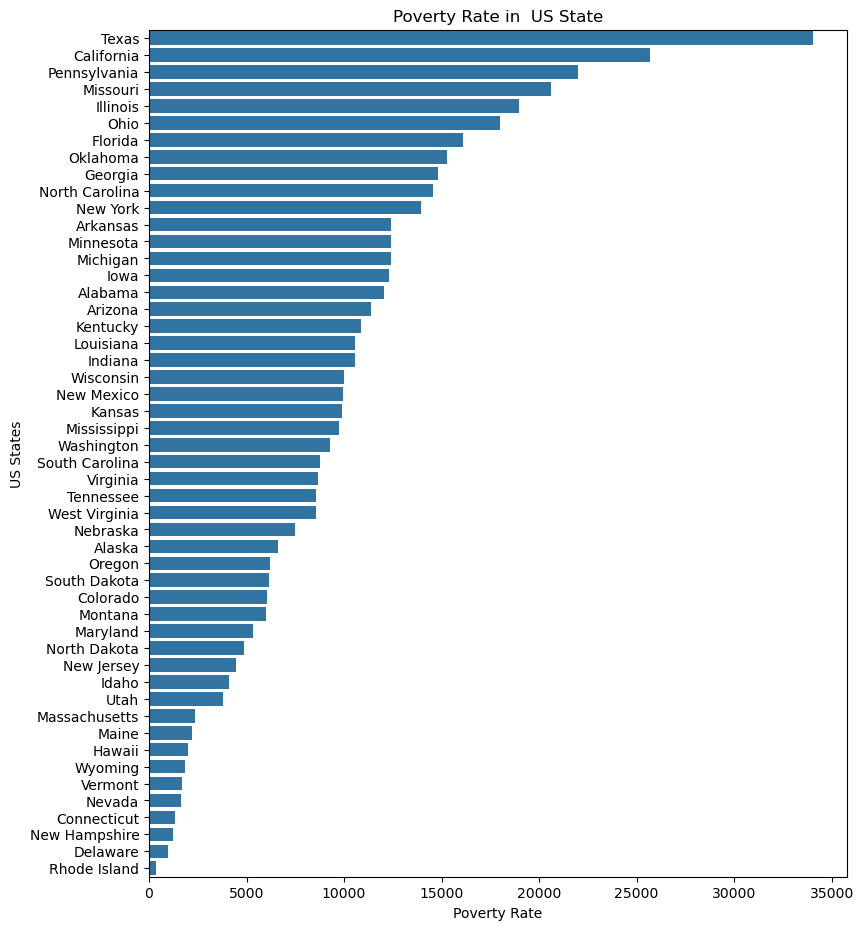

In [11]:
plt.figure(figsize=(9,11))
poverty_ = pd.DataFrame(df_pct_poverty.groupby("State")["poverty_rate"].sum())
poverty_=poverty_.sort_values(by="poverty_rate",ascending=False)
poverty_chart =  sns.barplot(poverty_,x="poverty_rate",y="State")
plt.title("Poverty Rate in  US State")
plt.xlabel("Poverty Rate")
plt.ylabel("US States")

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [12]:

df_pct_completed_hs.head()
df_pct_completed_hs["State"] = df_pct_completed_hs["Geographic Area"].map(state_dict)
hs_chart = df_pct_completed_hs[["State","percent_completed_hs"]]
hs_chart.loc[:, "percent_completed_hs"] = pd.to_numeric(
    hs_chart["percent_completed_hs"].replace("-", None)
)
hs_chart = hs_chart.groupby("State")["percent_completed_hs"].mean().reset_index()
hs_chart = hs_chart.sort_values(by="State",ascending=True)

<Axes: xlabel='percent_completed_hs', ylabel='State'>

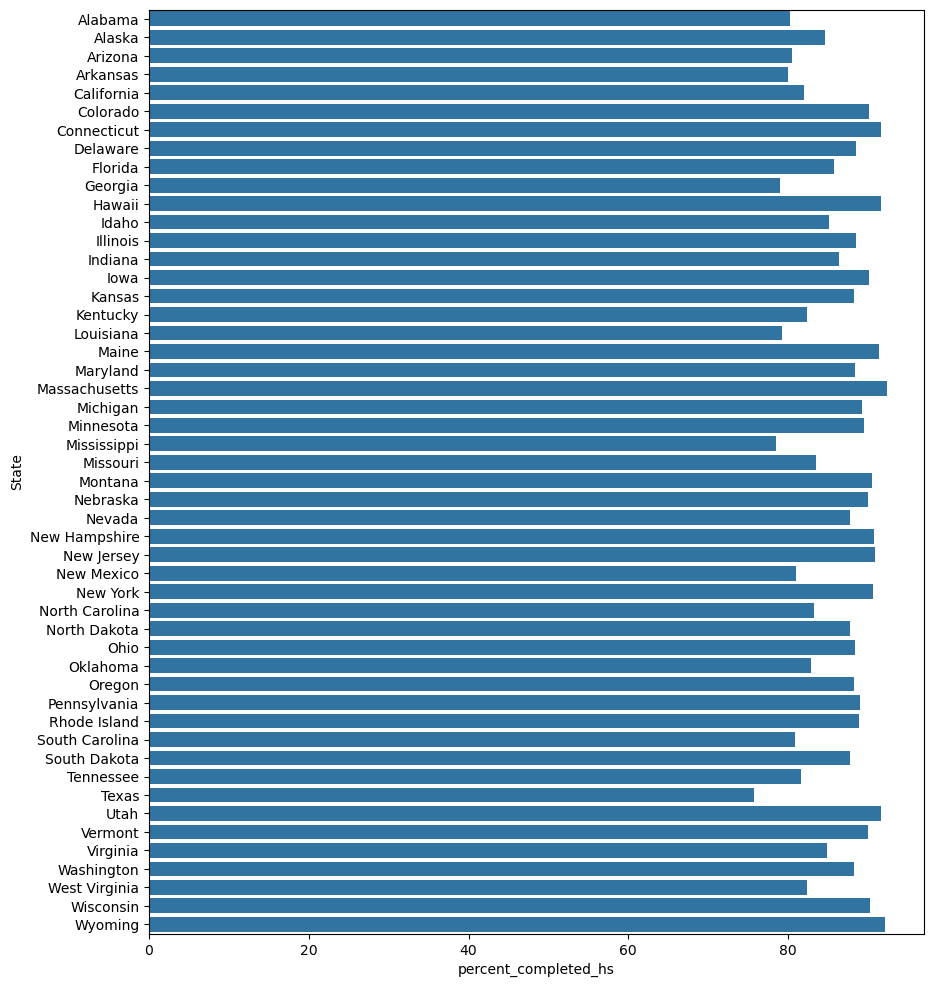

In [13]:
plt.figure(figsize=(10,12))
sns.barplot(y=hs_chart["State"],x=hs_chart["percent_completed_hs"])

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [14]:
merged_pr_hs = pd.merge(poverty_,hs_chart,how="inner",on="State")
merged_pr_hs.tail()
merged_pr_hs["percent_completed_hs"] = pd.to_numeric( merged_pr_hs["percent_completed_hs"])



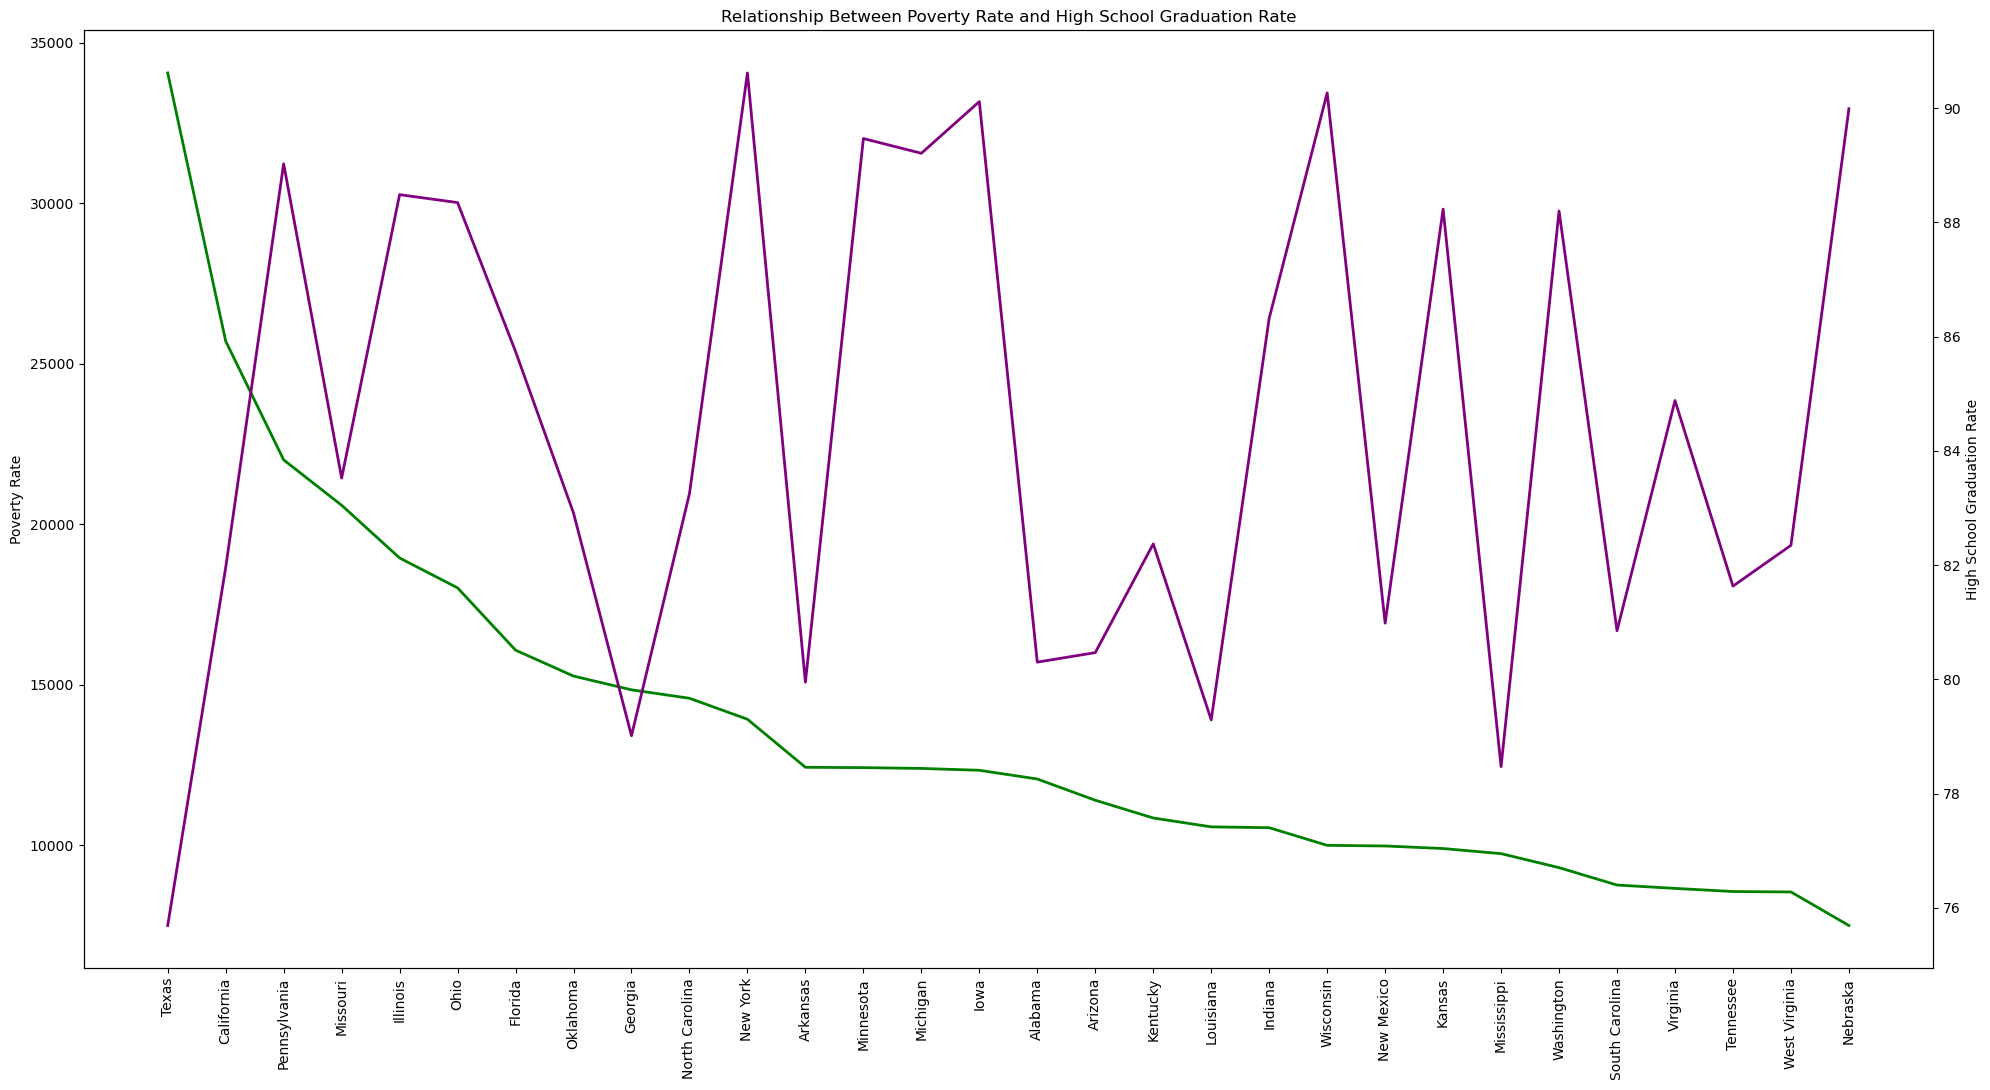

In [15]:
plt.figure(figsize=(20,11))
x_axis = plt.gca()
y_axis = x_axis.twinx() #to show same value on x axis ie state 

x_axis.plot(merged_pr_hs["State"][:-20],merged_pr_hs["poverty_rate"][:-20],color="green",linewidth=2)
y_axis.plot(merged_pr_hs["State"][:-20],merged_pr_hs["percent_completed_hs"][:-20],color="purple",linewidth=2)
x_axis.set_ylabel("Poverty Rate")
y_axis.set_ylabel("High School Graduation Rate")


# plt.xticks(

#     rotation=90,
#     fontsize=15
# )
x_axis.tick_params(axis='x', labelrotation=90)  # rotate labels vertically

plt.title("Relationship Between Poverty Rate and High School Graduation Rate")
plt.tight_layout()
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

<Figure size 2000x1100 with 0 Axes>

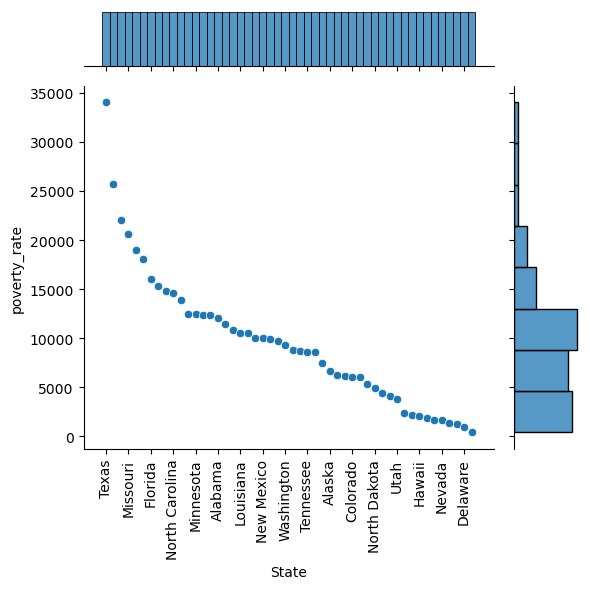

In [16]:
plt.figure(figsize=(20,11))

sns.jointplot(data=merged_pr_hs,x="State",y="poverty_rate")
plt.xticks(range(0, len(merged_pr_hs["State"]), 3),
           merged_pr_hs["State"][::3],rotation=90)#showing gap between the x axis label 
plt.tight_layout()
plt.show()

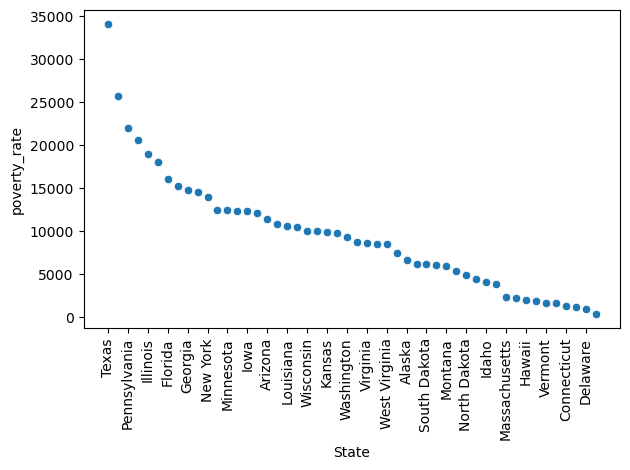

In [17]:
# plt.figure(figsize=(20,11))

sns.scatterplot(data=merged_pr_hs,x="State",y="poverty_rate")
plt.xticks(range(0, len(merged_pr_hs["State"]), 2),
           merged_pr_hs["State"][::2],rotation=90)
plt.tight_layout()
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

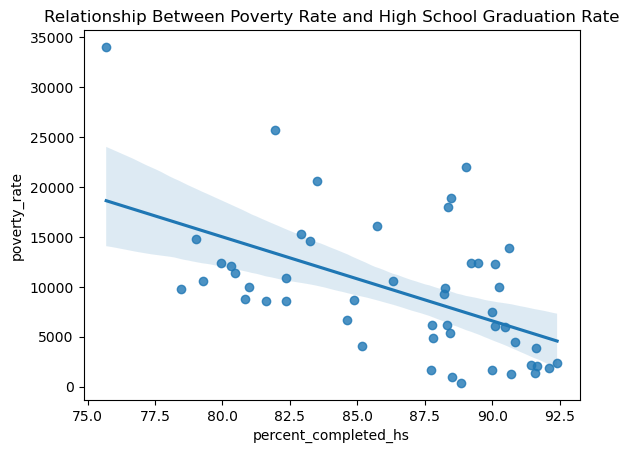

In [18]:

sns.regplot(data=merged_pr_hs,x="percent_completed_hs",y="poverty_rate")
# plt.xticks(range(0, len(merged_pr_hs["State"]), 2),
#            merged_pr_hs["State"][::2],rotation=90)
# plt.tight_layout()
plt.title("Relationship Between Poverty Rate and High School Graduation Rate")
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [19]:
df_share_race_city["State"] = df_share_race_city["Geographic area"].map(state_dict)

cols = ["share_white","share_black","share_native_american","share_asian","share_hispanic"]

df_share_race_city[cols] = df_share_race_city[cols].apply(pd.to_numeric, errors="coerce")
df_share_race_city

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,State
0,AL,Abanda CDP,67.20,30.20,0.00,0.00,1.60,Alabama
1,AL,Abbeville city,54.40,41.40,0.10,1.00,3.10,Alabama
2,AL,Adamsville city,52.30,44.90,0.50,0.30,2.30,Alabama
3,AL,Addison town,99.10,0.10,0.00,0.10,0.40,Alabama
4,AL,Akron town,13.20,86.50,0.00,0.00,0.30,Alabama
...,...,...,...,...,...,...,...,...
29263,WY,Woods Landing-Jelm CDP,95.90,0.00,0.00,2.10,0.00,Wyoming
29264,WY,Worland city,89.90,0.30,1.30,0.60,16.60,Wyoming
29265,WY,Wright town,94.50,0.10,1.40,0.20,6.20,Wyoming
29266,WY,Yoder town,97.40,0.00,0.00,0.00,4.00,Wyoming


In [20]:
share_fig = df_share_race_city.groupby("State")[[
"share_white",
"share_black",
"share_native_american",
"share_asian",
"share_hispanic"
]].mean().reset_index()

share_fig

,State,share_white,share_black,share_native_american,share_asian,share_hispanic
0,Alabama,72.51,23.32,0.66,0.48,2.98
1,Alaska,45.65,0.57,45.86,1.39,2.15
2,Arizona,59.93,0.95,28.59,0.73,20.14
3,Arkansas,78.45,16.30,0.76,0.48,4.27
4,California,71.87,2.69,1.72,5.57,29.65
5,Colorado,87.77,0.92,1.62,1.15,17.90
6,Connecticut,86.11,4.99,0.66,2.99,7.98
7,Delaware,76.25,15.39,0.52,2.00,7.42
8,Florida,78.67,13.37,0.46,1.62,16.53
9,Georgia,62.59,30.63,0.30,1.49,6.42


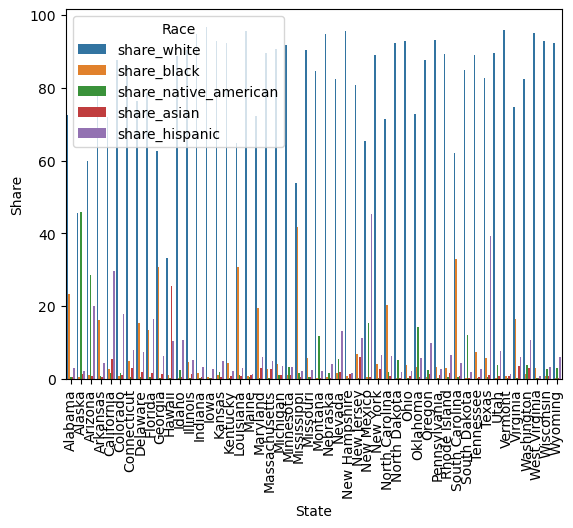

In [21]:
share_long = share_fig.melt(
    id_vars="State",
    var_name="Race",
    value_name="Share"
)

sns.barplot(data=share_long, x="State", y="Share", hue="Race")

plt.xticks(rotation=90)
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [22]:
Race= {'A':'Asian', 'W':'White', 'H':'Hispanic', 'B':'Black', 'O':'Other Race','unknown':'unknown','N':'Native American'}
df_fatalities['FRace']= df_fatalities['race'].map(Race)
death_race=df_fatalities['FRace'].value_counts().reset_index(name="Total")


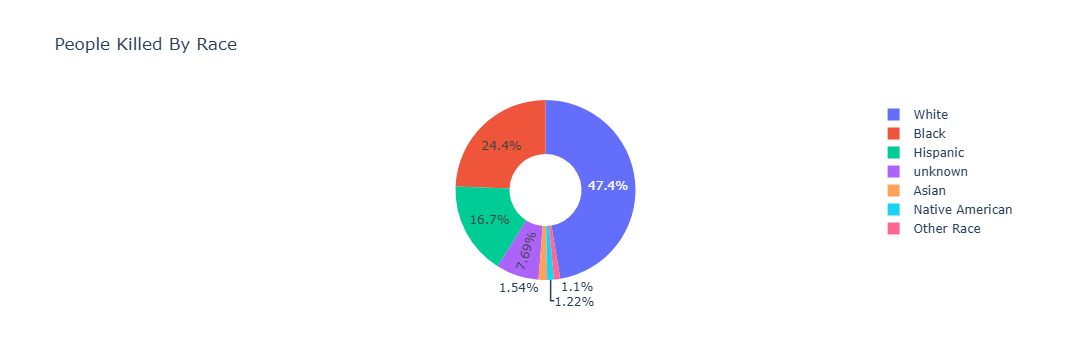

In [23]:
px.pie(death_race,names=death_race["FRace"],values=death_race["Total"],hole=0.4,title="People Killed By Race")


# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [36]:
gender_death_rate=df_fatalities["gender"].apply(lambda x: "Male" if x == "M" else "Female")
gender_death_rate = gender_death_rate.value_counts().reset_index()
gender_death_rate

,gender,count
0,Male,2428
1,Female,107


<Axes: xlabel='gender', ylabel='count'>

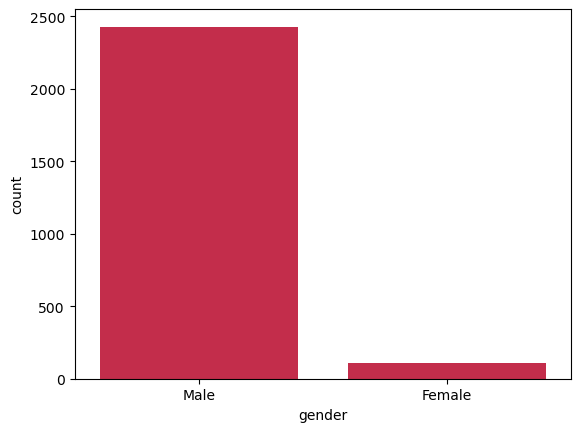

In [47]:
# plt.figure(figsize=(11,12))
sns.barplot(data=gender_death_rate,x="gender",
           y="count",color="crimson")


# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [69]:

manner_death_chart=df_fatalities.groupby(["manner_of_death","age"])["age"].count().reset_index(name="total")


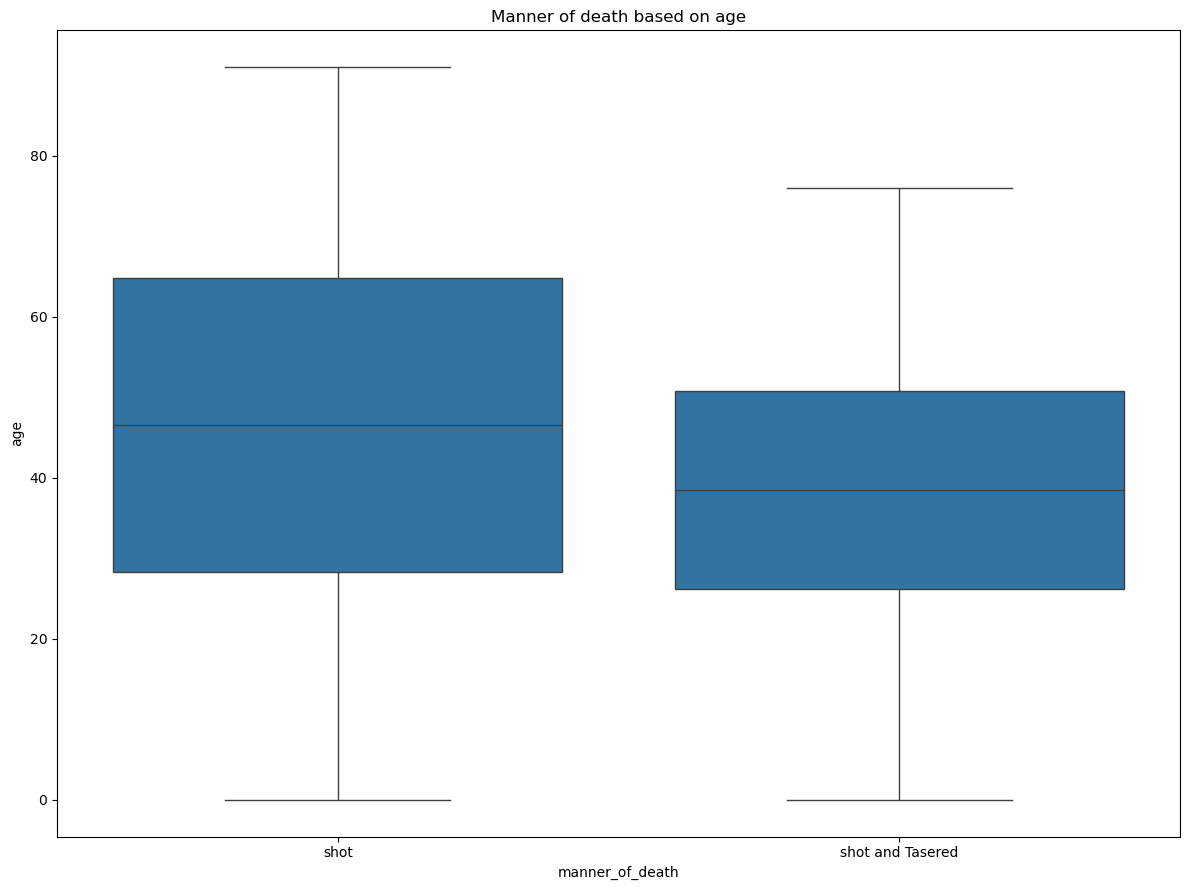

In [70]:
plt.figure(figsize=(12,9))
sns.boxplot(data=manner_death_chart,x="manner_of_death",y="age")
plt.title("Manner of death based on age")
plt.tight_layout()
# plt.xticks(rotation=45)
plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [94]:
armed_chart=df_fatalities["armed"].value_counts().reset_index(name="total")
armed_chart=armed_chart.query("total > 8")

<Axes: xlabel='total', ylabel='armed'>

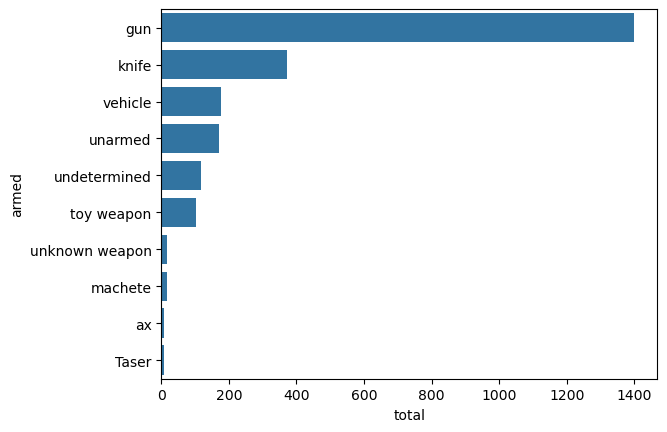

In [95]:
sns.barplot(data=armed_chart,x="total",y="armed")

Text(0.5, 1.0, 'people killed by police gun vs unarmed ')

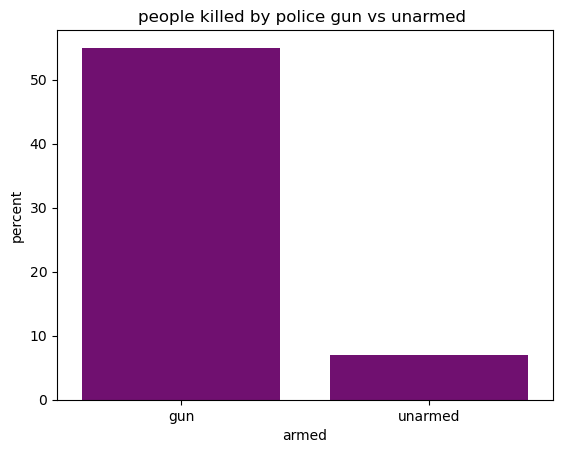

In [140]:
t = (df_fatalities["armed"].value_counts(normalize=True)*100).reset_index(name="percent")
t["percent"] =  round(t["percent"])
t= t.query("percent > 0 and armed in ['gun','unarmed']")
sns.barplot(data=t,x="armed",y="percent",color="purple")
plt.title("people killed by police gun vs unarmed ")


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [154]:
age_chart= (df_fatalities["age"].value_counts(normalize=True)*100).reset_index(name="total")
print(age_chart[age_chart["age"]==25])

    age  total
0 25.00   4.06


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

Text(0.5, 1.0, 'distribution of ages of the people killed by police')

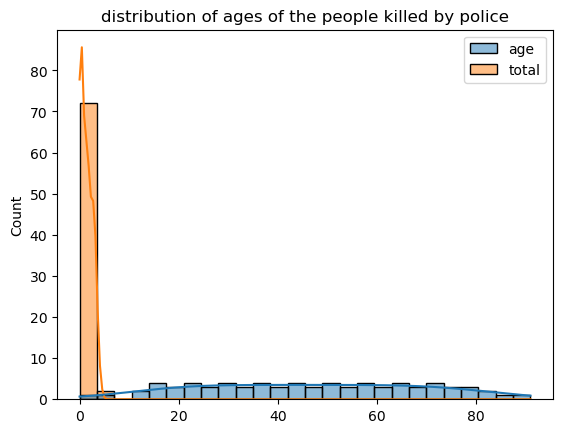

In [155]:
sns.histplot(age_chart,bins=26,kde=True)
plt.title("distribution of ages of the people killed by police")


Create a seperate KDE plot for each race. Is there a difference between the distributions? 

Text(0, 0.5, 'Race')

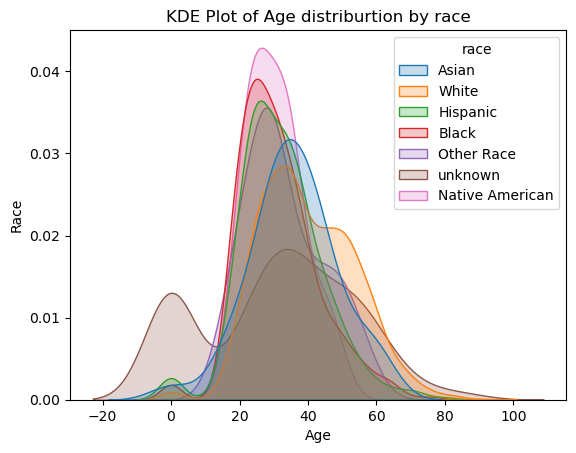

In [163]:
kde_chart = sns.kdeplot(df_fatalities,x="age",hue=df_fatalities["race"].map(Race),fill=True,common_norm=False)
plt.title("KDE Plot of Age distriburtion by race")
plt.xlabel("Age")
plt.ylabel("Race")


# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [168]:
race_death= df_fatalities["race"].value_counts().reset_index(name="total")
race_death["race"]= race_death["race"].map(Race)
race_death

,race,total
0,White,1201
1,Black,618
2,Hispanic,423
3,unknown,195
4,Asian,39
5,Native American,31
6,Other Race,28


Text(0, 0.5, 'Total')

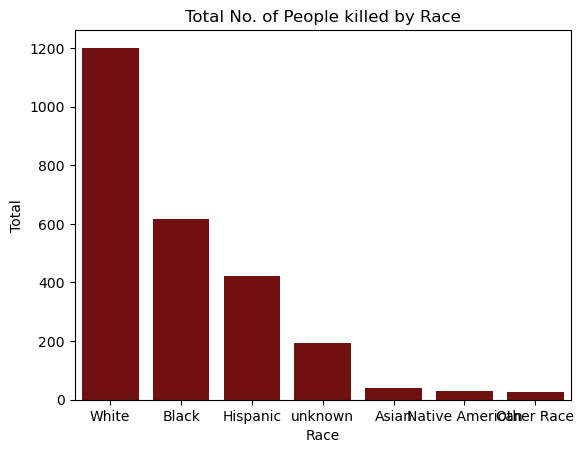

In [178]:
sns.barplot(data=race_death,x="race",y="total",color="maroon")
plt.title("Total No. of People killed by Race")
plt.xlabel("Race")
plt.ylabel("Total")


# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [189]:
mental_illness = round(df_fatalities["signs_of_mental_illness"].value_counts(normalize=True)*100).reset_index(name="total")
mental_illness["signs_of_mental_illness"] = mental_illness["signs_of_mental_illness"].apply(lambda x: "Yes" if x== True else "No")

,signs_of_mental_illness,total
0,No,75.00
1,Yes,25.00


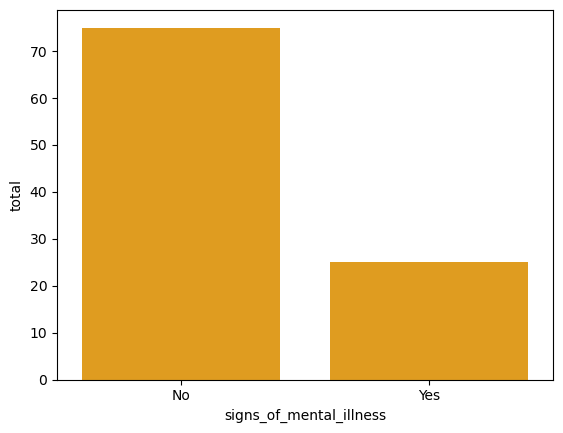

In [197]:
sns.barplot(data=mental_illness,x="signs_of_mental_illness",y="total",color="orange")
mental_illness

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [223]:
police_killing_City=df_fatalities["city"].value_counts().reset_index(name="total")
police_killing_City = police_killing_City.query(" total > 5")
police_killing_City

,city,total
0,Los Angeles,39
1,Phoenix,31
2,Houston,27
3,Chicago,25
4,Las Vegas,21
5,San Antonio,20
6,Columbus,19
7,Miami,18
8,Austin,18
9,St. Louis,15


Text(0, 0.5, 'Total no. of Police killing')

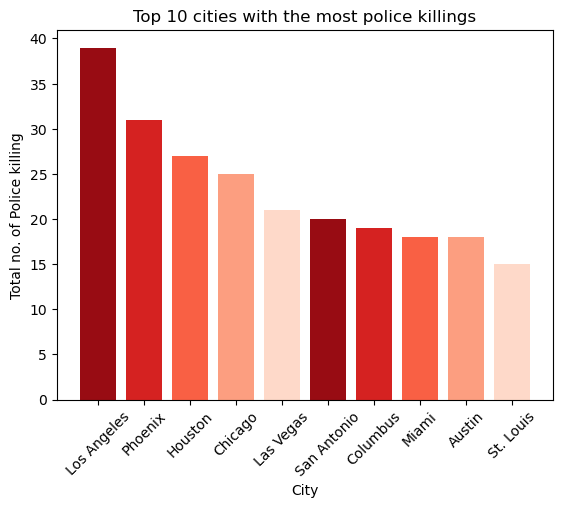

In [266]:
police_killing_City=police_killing_City.sort_values(by="total",ascending=False)
colors = plt.cm.Reds(np.linspace(0.9, 0.15, 5))
plt.bar(data=police_killing_City,x=police_killing_City["city"][:10],height=police_killing_City["total"][:10],color=colors)
plt.xticks(rotation=45)

plt.title("Top 10 cities with the most police killings")
plt.xlabel("City")
plt.ylabel("Total no. of Police killing")


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [299]:

top10_cities= df_fatalities.groupby("city")["city"].count().sort_values(ascending=False).head(10).index
top10_cities


Index(['Los Angeles', 'Phoenix', 'Houston', 'Chicago', 'Las Vegas',
       'San Antonio', 'Columbus', 'Austin', 'Miami', 'St. Louis'],
      dtype='object', name='city')

In [317]:
race_share = (
    df_fatalities[df_fatalities["city"].isin(top10_cities)]
    .groupby(["city","FRace"]).size().reset_index(name="kill_count")
)
race_share


,city,FRace,kill_count
0,Austin,Black,3
1,Austin,Hispanic,2
2,Austin,White,13
3,Chicago,Black,21
4,Chicago,Hispanic,1
5,Chicago,White,2
6,Chicago,unknown,1
7,Columbus,Black,11
8,Columbus,Other Race,1
9,Columbus,White,6


In [320]:
killing_pivot =race_share.pivot(index="city",columns="FRace",values="kill_count").fillna(0)
killing_pivot


FRace,Asian,Black,Hispanic,Native American,Other Race,White,unknown
city,,,,,,,
Austin,0.00,3.00,2.00,0.00,0.00,13.00,0.00
Chicago,0.00,21.00,1.00,0.00,0.00,2.00,1.00
Columbus,0.00,11.00,0.00,0.00,1.00,6.00,1.00
Houston,1.00,15.00,6.00,1.00,0.00,3.00,1.00
Las Vegas,0.00,3.00,5.00,0.00,0.00,9.00,4.00
Los Angeles,1.00,10.00,19.00,0.00,0.00,6.00,3.00
Miami,0.00,8.00,6.00,0.00,0.00,3.00,1.00
Phoenix,0.00,2.00,11.00,3.00,0.00,12.00,3.00
San Antonio,0.00,3.00,12.00,0.00,0.00,3.00,2.00


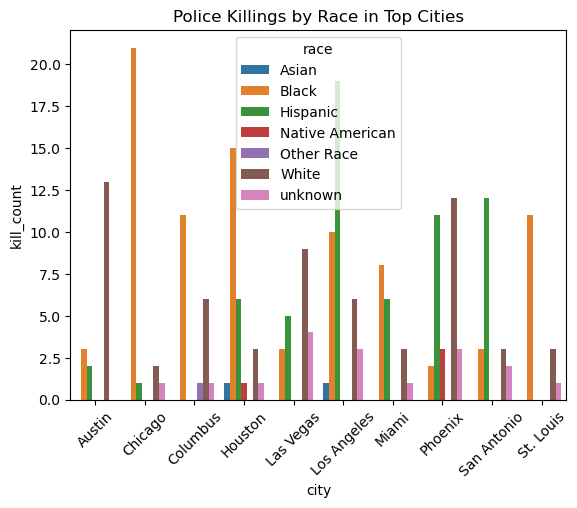

In [330]:
killing_long = killing_pivot.reset_index().melt(
    id_vars="city",
    var_name="race",
    value_name="kill_count"
)
killing_long

sns.barplot(
    data=killing_long,
    x="city",
    y="kill_count",
    hue="race"
)

plt.xticks(rotation=45)
plt.title("Police Killings by Race in Top Cities")
plt.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [354]:
choro_chart = df_fatalities["state"].value_counts().reset_index(name="total")
choro_chart["state name"]= choro_chart["state"].map(state_map)

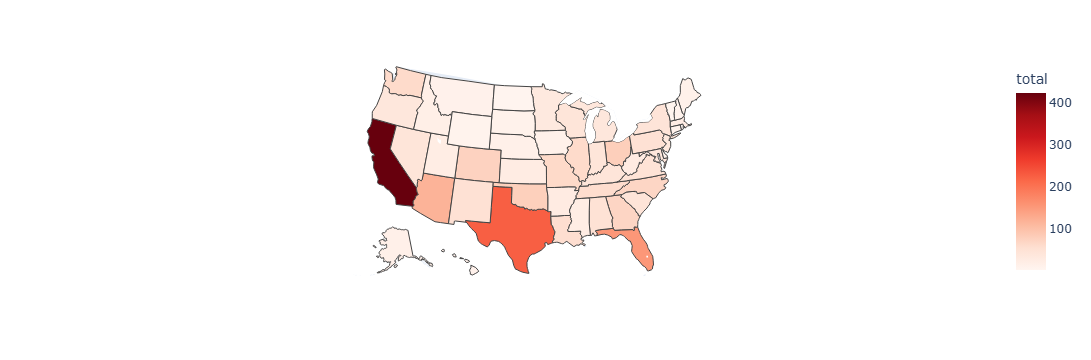

In [359]:
choro_figure = px.choropleth(choro_chart,locations="state",locationmode="USA-states",color="total",color_continuous_scale="Reds",scope="usa",hover_name="state name")
choro_figure.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [401]:
df_fatalities["year"] = pd.to_datetime(df_fatalities["date"]).dt.year
yearly_kill = df_fatalities["year"].value_counts().reset_index(name="kill_count")
yearly_kill


C:\Users\hp\AppData\Local\Temp\ipykernel_9628\3897496151.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fatalities["year"] = pd.to_datetime(df_fatalities["date"]).dt.year


,year,kill_count
0,2015,991
1,2016,963
2,2017,581


Text(0, 0.5, 'No. of Kill Count')

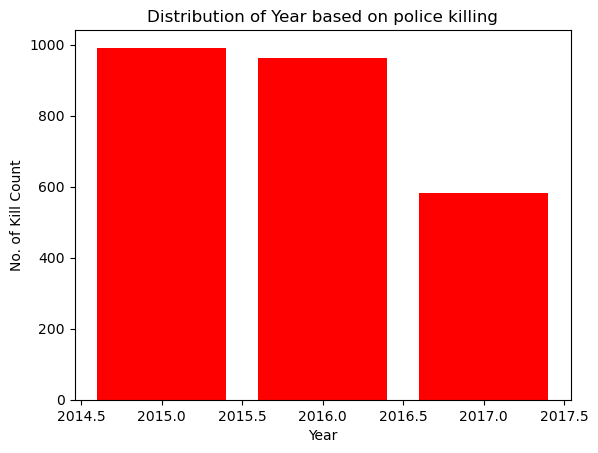

In [423]:

plt.bar(yearly_kill["year"],yearly_kill["kill_count"],color="Red")
plt.title("Distribution of Year based on police killing")
plt.xlabel("Year")
plt.ylabel("No. of Kill Count")
          

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).